In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import ast
import arviz as az
import scipy.signal as ss

import h5py
# import glob

import sxs

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import ringdown as rd

In [4]:
t0 = 1126259462.423
ra = 1.952318922
dec = -1.26967171703
psi = 0.824043851821

In [13]:
mtot = 330

In [14]:
fit = rd.Fit.from_config(f'/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1155/mtot{mtot}/220_SXS_BBH_1155_fmin10Hz_ppSNR20_mtot{mtot}_inclined/engine/1126259462.423000/config.ini')

In [15]:
config_dict = ast.literal_eval(fit.attrs['config'])

In [16]:
mf = float(config_dict['model']['m_min']) * 2
tm = rd.qnms.T_MSUN * mf
tm

0.0015467470861452455

In [17]:
tm * 500

0.7733735430726227

In [18]:
wfs = {i: pd.read_hdf(f'/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155/mtot{mtot}/SXS_BBH_1155_fmin10Hz_ppSNR20_mtot{mtot}_inclined_{i}.hdf5', key=i) for i in fit.ifos}

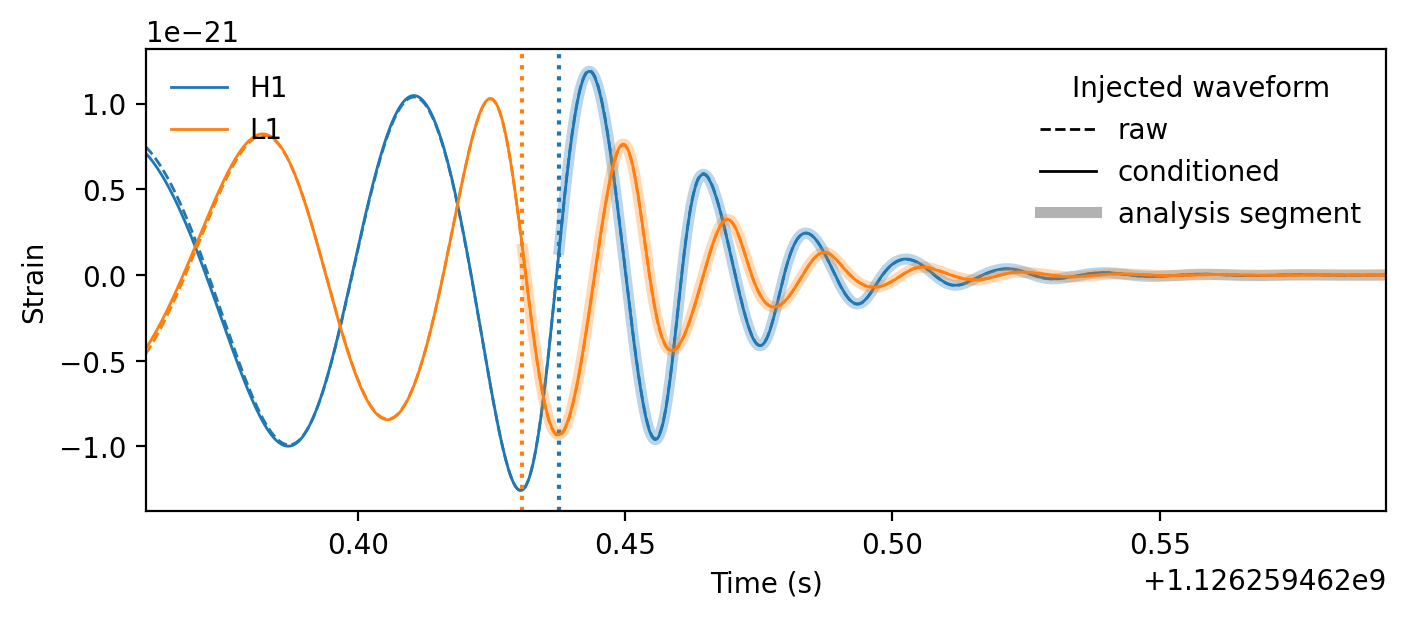

In [19]:
fig, ax = plt.subplots(figsize=(8, 3))

for i, d in fit.data.items():
    l, = ax.plot(d, lw=1, label=i)
    ax.plot(wfs[i], lw=1, ls='--', color=l.get_color())
    ax.plot(fit.analysis_data[i], lw=4, alpha=0.3, color=l.get_color())
    ax.axvline(fit.start_times[i], color=l.get_color(), ls=':')

ax.set_xlim(fit.start_times['H1'] - 50 * tm, fit.start_times['H1'] + 100 * tm)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Strain')

leg1 = ax.legend(frameon=False, loc='upper left')
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='k', lw=1, ls='--'), plt.Line2D([], [], color='k', lw=1), plt.Line2D([], [], color='k', lw=4, alpha=0.3)],
                 ['raw', 'conditioned', 'analysis segment'], frameon=False, loc='upper right', title='Injected waveform')

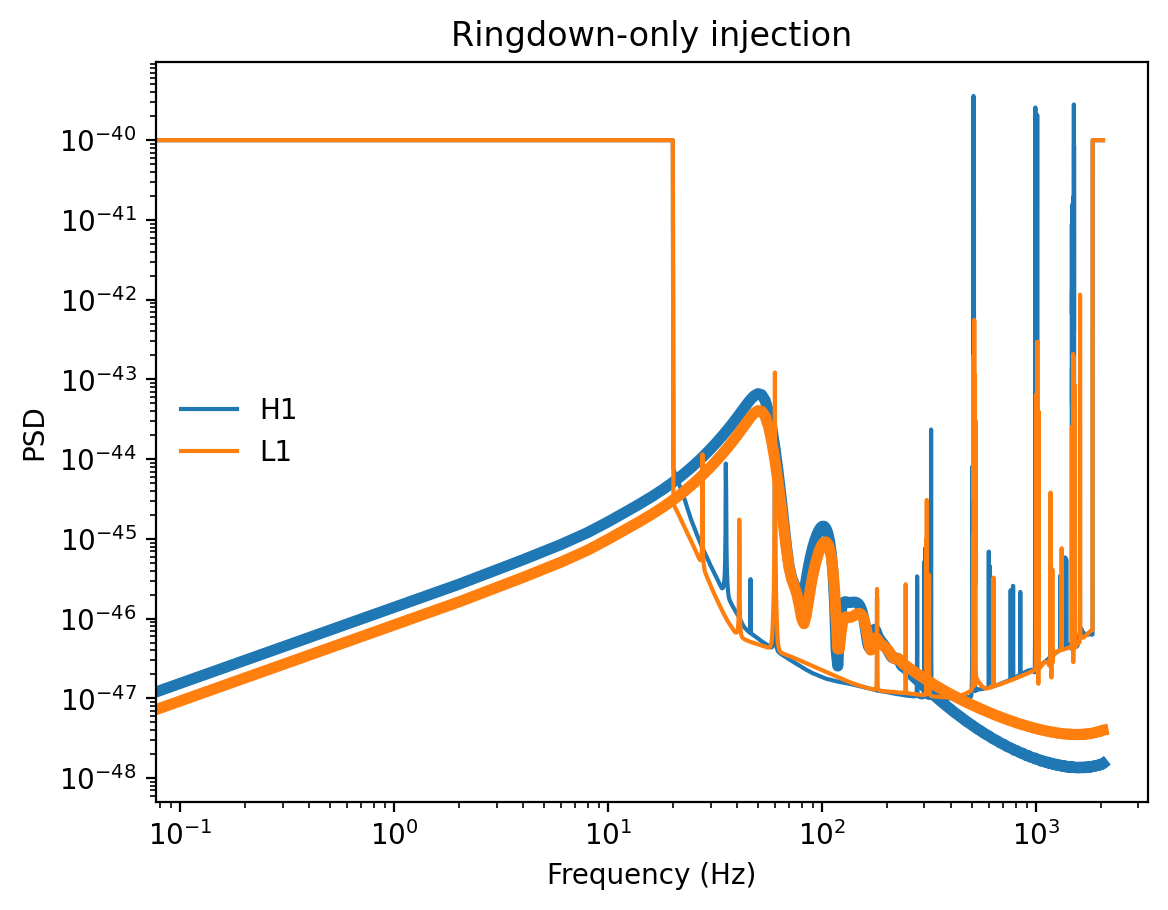

In [21]:
fig, ax = plt.subplots()
for i, psd in fit.psds.items():
    l, = ax.loglog(psd, label=i)
    dt = fit.analysis_data[i].delta_t
    h_freq = np.fft.rfft(fit.analysis_data[i].values)*dt
    fs = np.fft.rfftfreq(len(fit.analysis_data[i].time.values), d=dt)
    ax.loglog(fs, 4*fs*np.abs(h_freq)**2, lw=4, color=l.get_color())
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
ax.set_title('Ringdown-only injection')
ax.legend(frameon=False)

Shifting waveform such that the analysis segment still begins at the same t0 but only contains ringup:

In [18]:
T = tm * 500
dt0 = (T / tm) // 10
dt0

50.0

In [19]:
dt = wfs['H1'].index.values[1] - wfs['H1'].index.values[0]
shift = {i: np.arange(wfs[i].index.values[-1], wfs[i].index.values[-1] + T, dt) for i in fit.ifos}
(shift['H1'] == shift['L1']).all()

np.True_

In [20]:
### shifted time array
index_shift = {i: np.concatenate([wfs[i].index.values[len(shift[i]):], shift[i]]) for i in fit.ifos}

In [21]:
### same waveform but on shifted time array
wfs_shift = {i: rd.Data(data=wfs[i].values, index=index_shift[i], ifo=i) for i in fit.ifos}

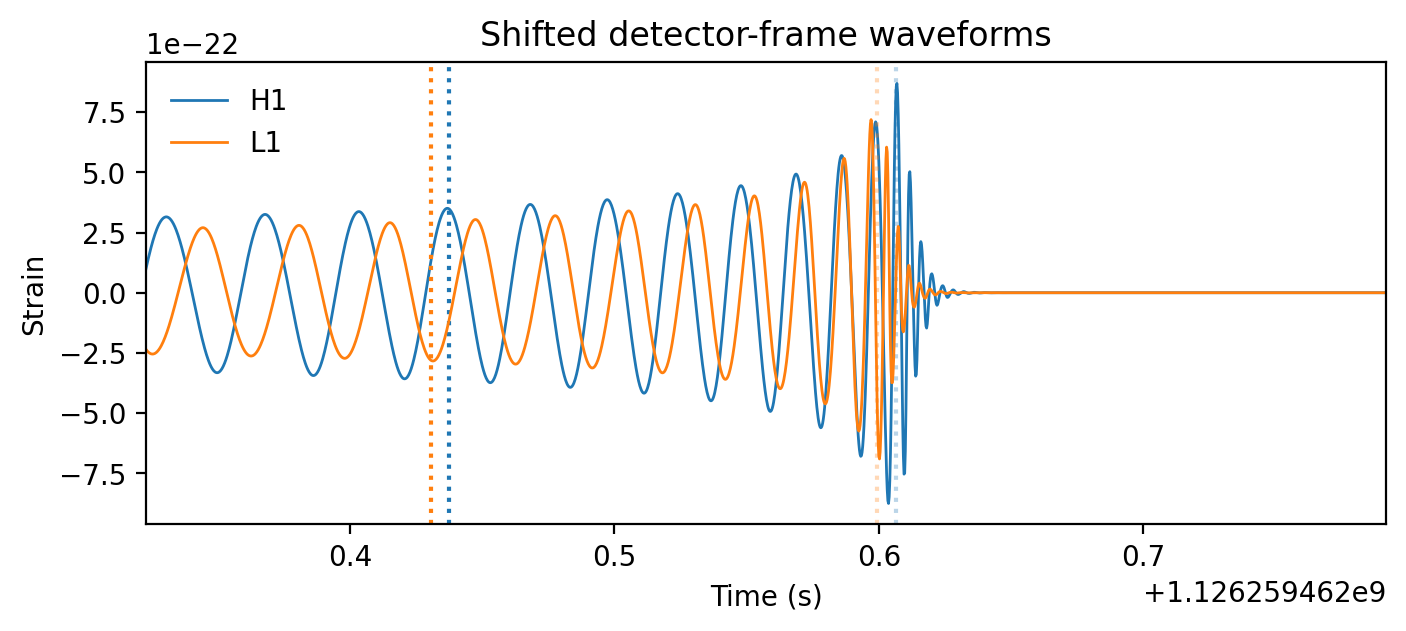

In [22]:
fig, ax = plt.subplots(figsize=(8, 3))

for i, d in wfs_shift.items():
    l, = ax.plot(d, lw=1, label=i)
    # ax.plot(wfs_shift[i], lw=1, ls='--', color=l.get_color())
    # ax.plot(fit.analysis_data[i], lw=4, alpha=0.3, color=l.get_color())
    ax.axvline(fit.start_times[i], color=l.get_color(), ls=':')
    ax.axvline(fit.start_times[i] + T, color=l.get_color(), ls=':', alpha=0.3)

ax.set_xlim(t0 - 0.1, t0 + T + 0.2)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Strain')
ax.set_title('Shifted detector-frame waveforms')

leg1 = ax.legend(frameon=False, loc='upper left')

Save the shifted waveforms to use for ringup-only injection:

In [23]:
for i, wf in wfs_shift.items():
    wf.to_hdf(f'/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155/mtot{mtot}/SXS_BBH_1155_fmin10Hz_ppSNR20_mtot{mtot}_inclined_ringup_{i}.hdf5', key=i)

Check that the analysis segment contains only ringup:

In [24]:
temp_fit = rd.Fit()
start_times = np.arange(0, dt0 * 11, dt0)
# start_times = np.linspace(450, 500, 11)
temp_fit.set_target(t0=t0, ra=ra, dec=dec, psi=psi, duration=T)
temp_fit.load_data({i: f'/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155/mtot{mtot}/SXS_BBH_1155_fmin10Hz_ppSNR20_mtot{mtot}_inclined_ringup_{i}.hdf5' for i in fit.ifos})

(1126259462.1230001, 1126259463.591736)

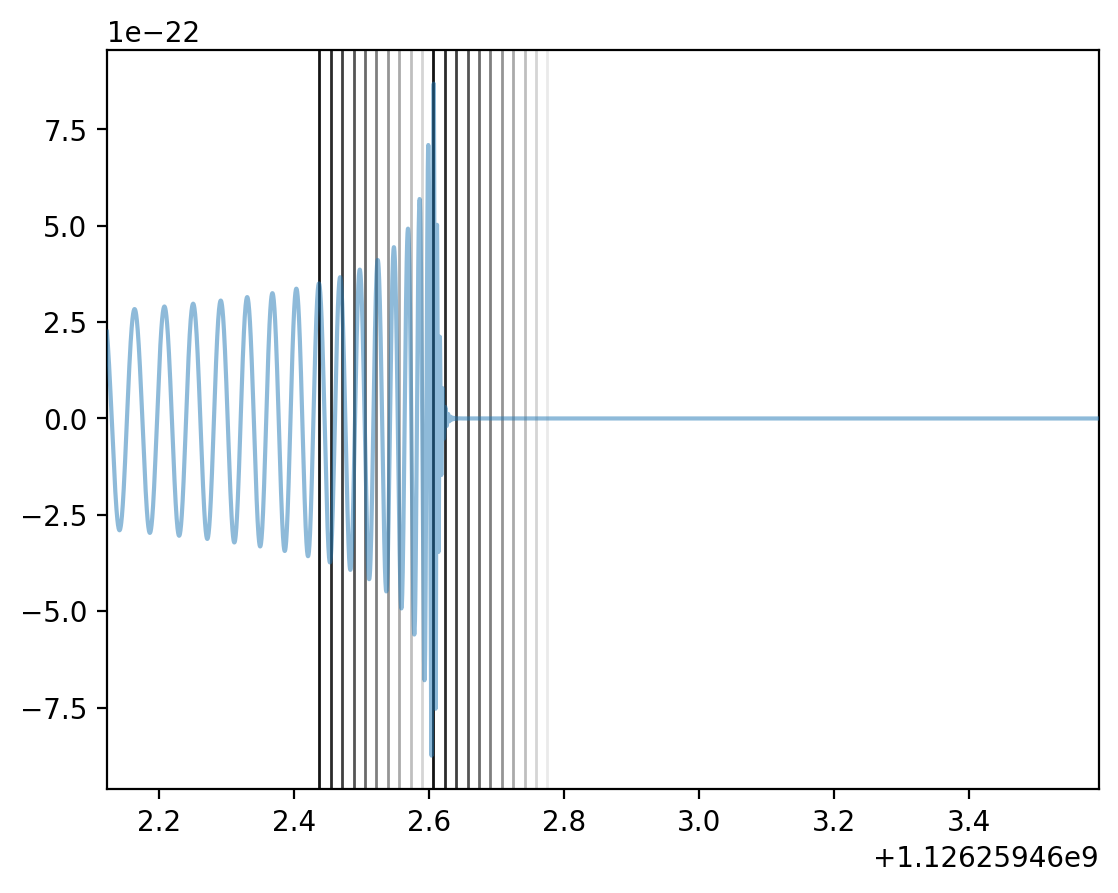

In [25]:
# l, = plt.plot(fit.data['H1'], lw=1)
plt.plot(temp_fit.data['H1'], lw=1.5, alpha=0.5, zorder=10)

# plt.axvline(fit.start_times['H1'], color='k', ls=':', lw=1)
# plt.axvline(temp_fit.start_times['H1'], color='k', lw=4, alpha=0.2)
for i, t in enumerate(start_times):
    plt.axvline(temp_fit.start_times['H1'] + t * tm, color='k', lw=1, alpha=1-(i+1)/(len(start_times)+1))
    plt.axvline(temp_fit.start_times['H1'] + t * tm + T, color='k', lw=1, alpha=1-(i+1)/(len(start_times)+1))
# plt.axvline(temp_fit.start_times['H1'], color='k', lw=4, alpha=0.2)

plt.xlim(t0 - 0.3, t0 + T + 1)

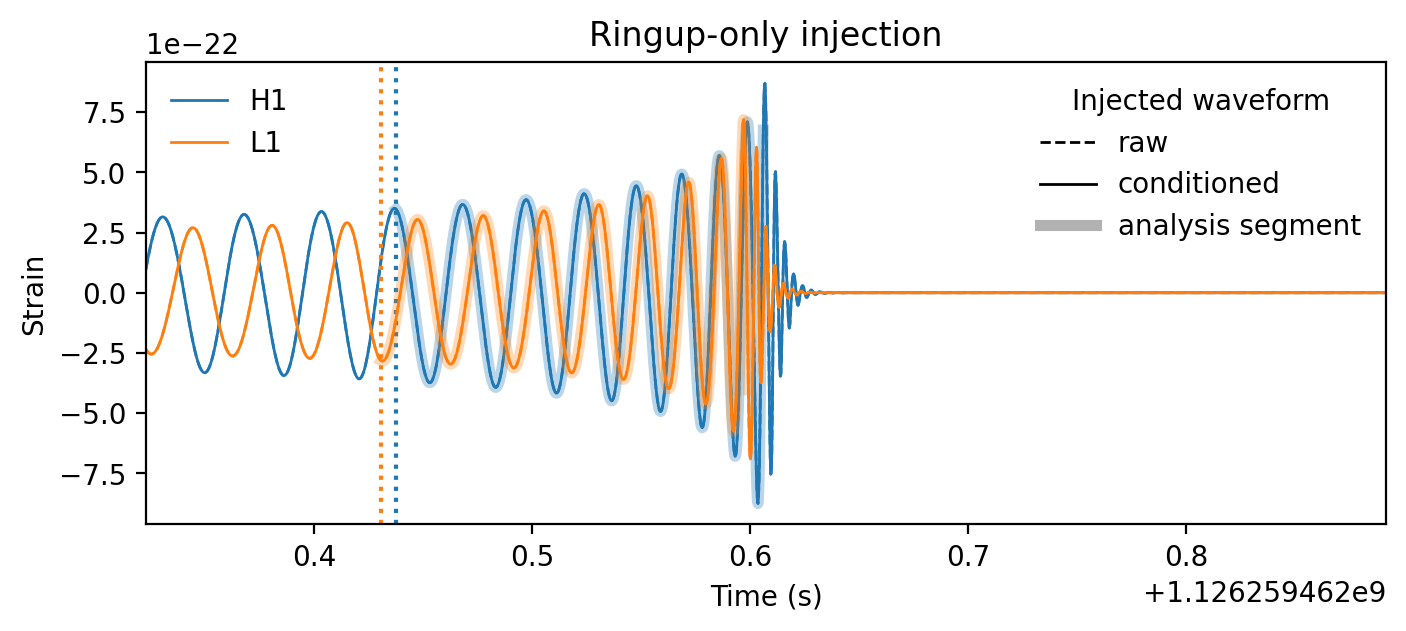

In [26]:
fig, ax = plt.subplots(figsize=(8, 3))

for i, d in temp_fit.data.items():
    l, = ax.plot(d, lw=1, label=i)
    ax.plot(wfs_shift[i], lw=1, ls='--', color=l.get_color())
    ax.plot(temp_fit.analysis_data[i], lw=4, alpha=0.3, color=l.get_color())
    ax.axvline(temp_fit.start_times[i], color=l.get_color(), ls=':')
    # ax.axvline(temp_fit.start_times[i] + T, color=l.get_color(), ls=':', alpha=0.3)

# ax.axvspan(fit.start_times['H1'] + 120 * tm, fit.start_times['H1'] + 120 * tm + T, color='k', alpha=0.1, lw=0)
ax.set_xlim(t0 - 0.1, t0 + T + 0.3)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Strain')
ax.set_title('Ringup-only injection')

leg1 = ax.legend(frameon=False, loc='upper left')
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='k', lw=1, ls='--'), plt.Line2D([], [], color='k', lw=1), plt.Line2D([], [], color='k', lw=4, alpha=0.3)],
                 ['raw', 'conditioned', 'analysis segment'], frameon=False, loc='upper right', title='Injected waveform')

In [27]:
temp_fit.acfs = fit.acfs.copy()

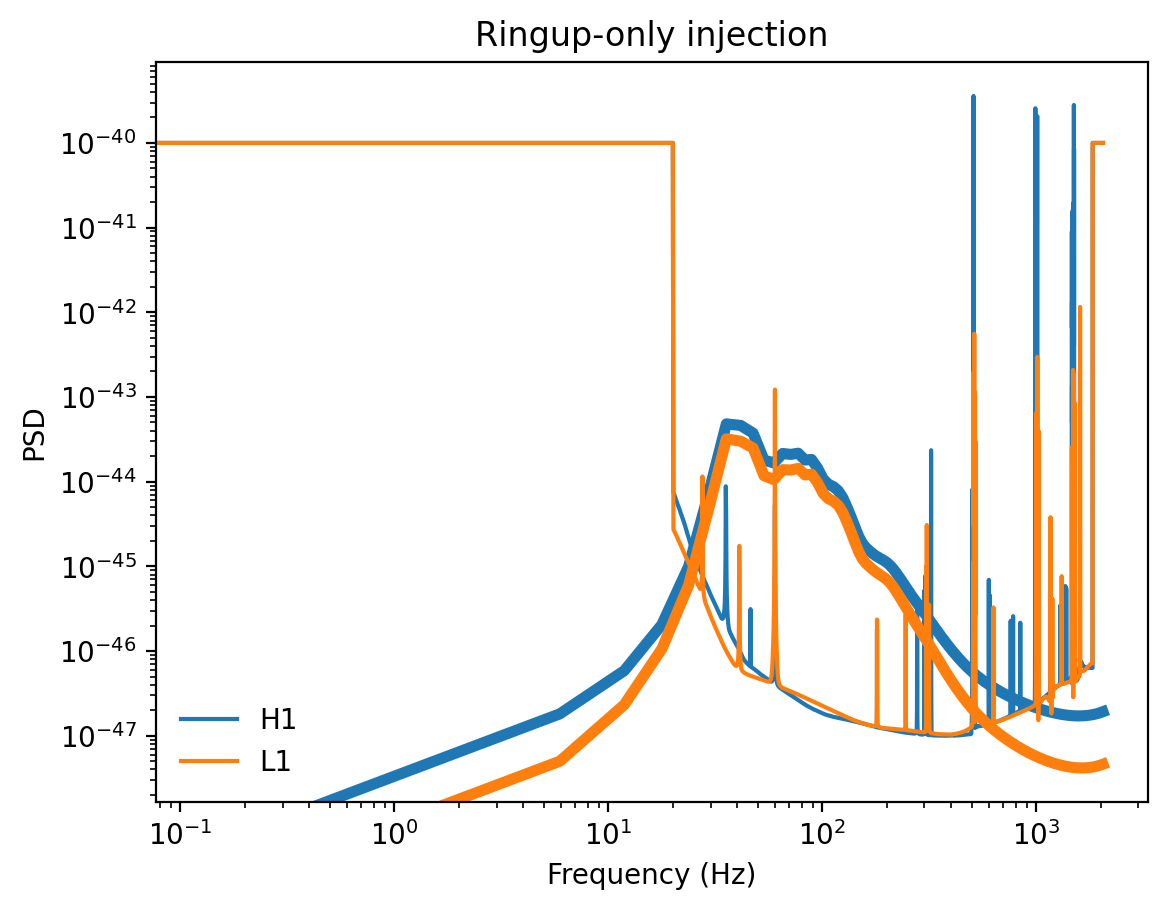

In [28]:
fig, ax = plt.subplots()
for i, psd in temp_fit.psds.items():
    l, = ax.loglog(psd, label=i)
    dt = temp_fit.analysis_data[i].delta_t
    h_freq = np.fft.rfft(temp_fit.analysis_data[i].values)*dt
    fs = np.fft.rfftfreq(len(temp_fit.analysis_data[i].time.values), d=dt)
    ax.loglog(fs, 4*fs*np.abs(h_freq)**2, lw=4, color=l.get_color())
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
ax.set_title('Ringup-only injection')
ax.legend(frameon=False)

In [29]:
temp_fit.condition_data(f_min=10, ds=1, trim=0)

In [30]:
temp_fit.acfs = fit.acfs.copy()

In [31]:
temp_fit.data['H1'][temp_fit.analysis_times['H1'][0]]

np.float64(3.467261831686288e-22)

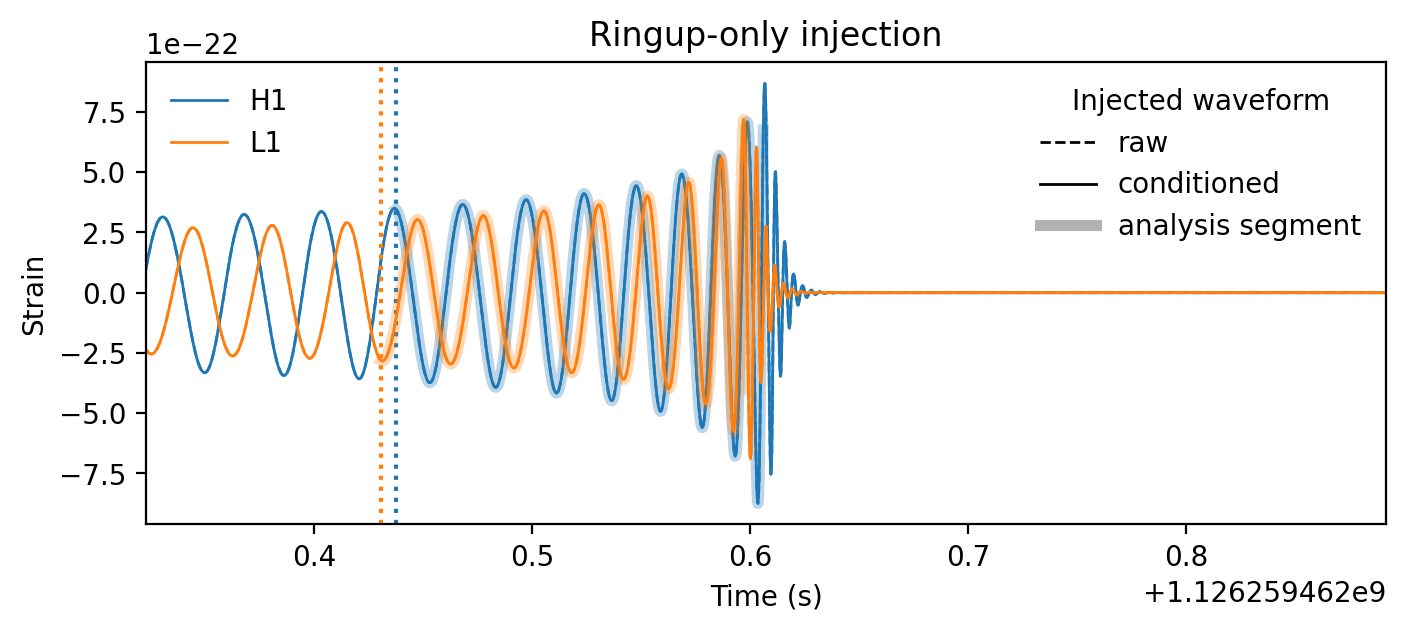

In [32]:
fig, ax = plt.subplots(figsize=(8, 3))

for i, d in temp_fit.data.items():
    l, = ax.plot(d, lw=1, label=i)
    ax.plot(wfs_shift[i], lw=1, ls='--', color=l.get_color())
    ax.plot(temp_fit.analysis_data[i], lw=4, alpha=0.3, color=l.get_color())
    ax.axvline(temp_fit.start_times[i], color=l.get_color(), ls=':')
    # ax.axvline(temp_fit.start_times[i] + T, color=l.get_color(), ls=':', alpha=0.3)

# ax.axvspan(fit.start_times['H1'] + 120 * tm, fit.start_times['H1'] + 120 * tm + T, color='k', alpha=0.1, lw=0)
ax.set_xlim(t0 - 0.1, t0 + T + 0.3)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Strain')
ax.set_title('Ringup-only injection')

leg1 = ax.legend(frameon=False, loc='upper left')
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='k', lw=1, ls='--'), plt.Line2D([], [], color='k', lw=1), plt.Line2D([], [], color='k', lw=4, alpha=0.3)],
                 ['raw', 'conditioned', 'analysis segment'], frameon=False, loc='upper right', title='Injected waveform')

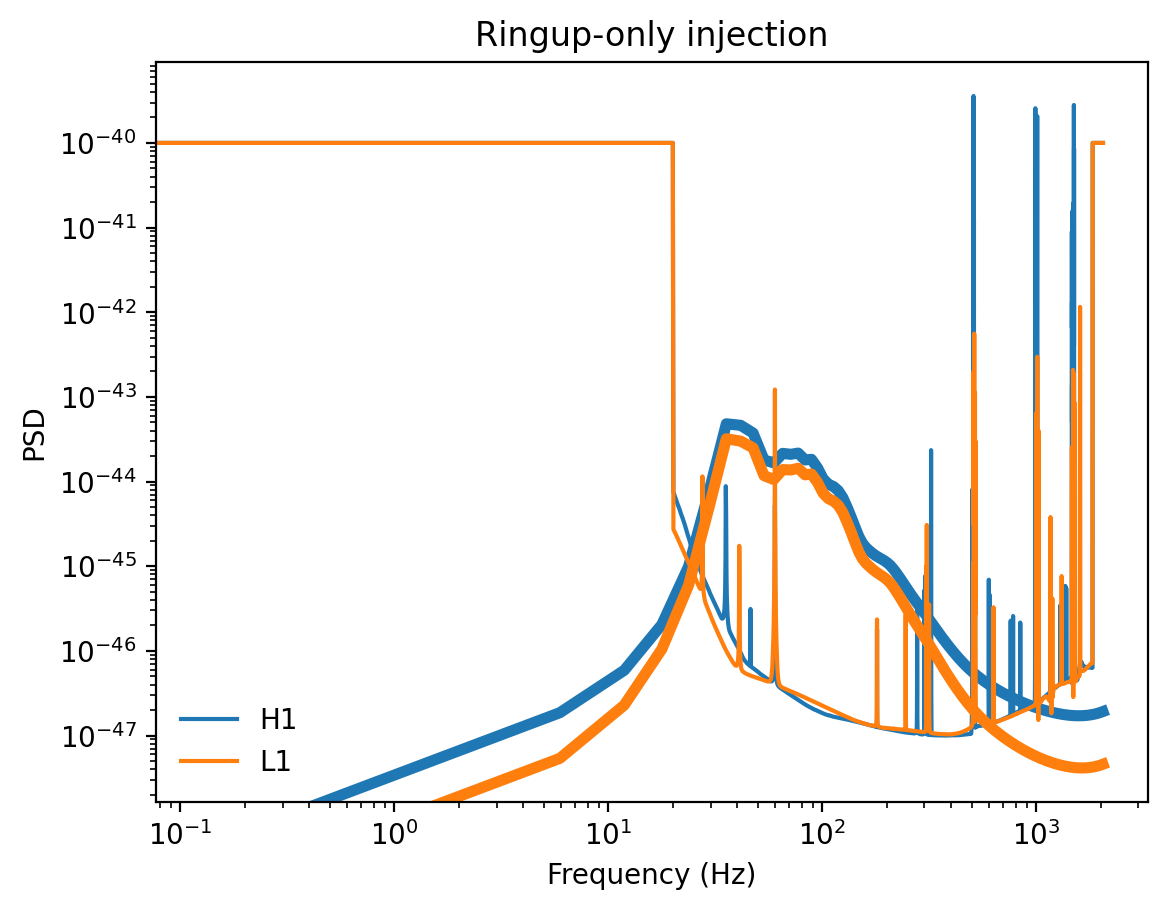

In [33]:
fig, ax = plt.subplots()
for i, psd in temp_fit.psds.items():
    l, = ax.loglog(psd, label=i)
    dt = temp_fit.analysis_data[i].delta_t
    h_freq = np.fft.rfft(temp_fit.analysis_data[i].values)*dt
    fs = np.fft.rfftfreq(len(temp_fit.analysis_data[i].time.values), d=dt)
    ax.loglog(fs, 4*fs*np.abs(h_freq)**2, lw=4, color=l.get_color())
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
ax.set_title('Ringup-only injection')
ax.legend(frameon=False)

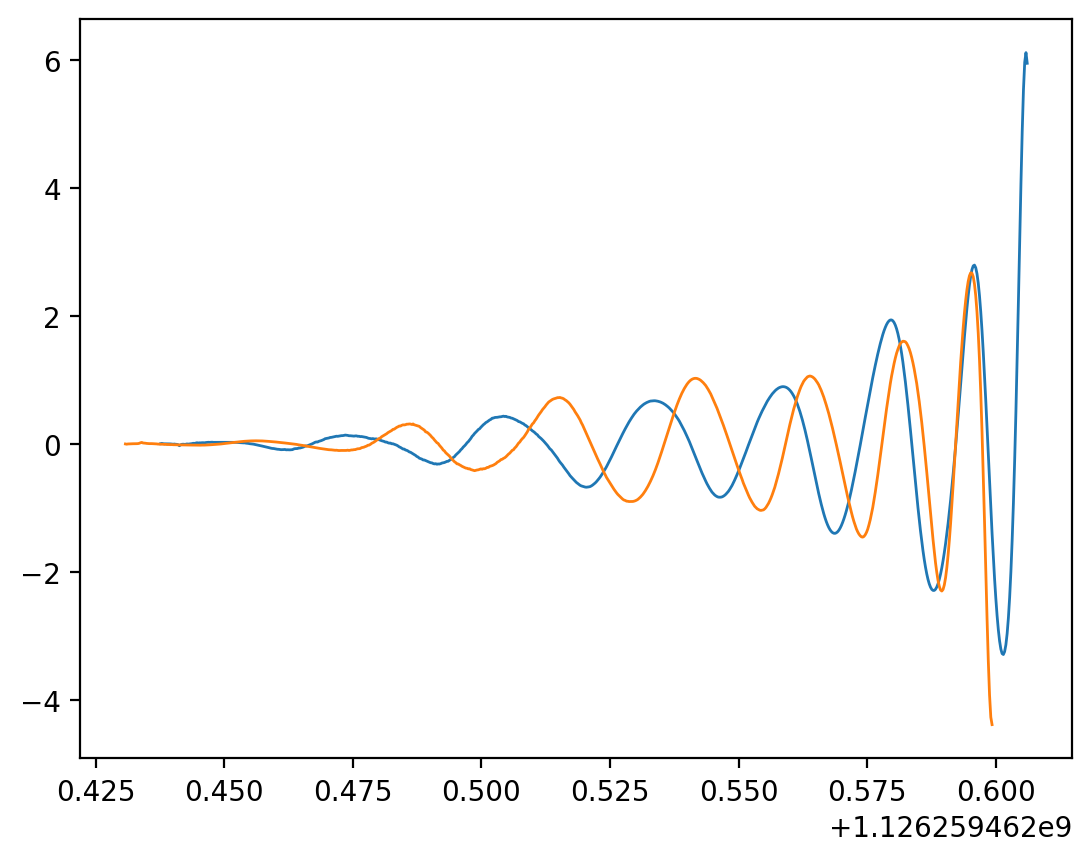

In [34]:
wd = temp_fit.whiten(temp_fit.analysis_data)

for i, d in wd.items():
    plt.plot(d, lw=1, label=i)

In [35]:
cumsnr = {i: np.sqrt(np.cumsum(d*d)) for i, d in wd.items()}
ppSNR = float(np.linalg.norm([cs.iloc[-1] for cs in cumsnr.values()]))
print(ppSNR)

33.41296352352089


In [36]:
dt0 * 11, dt0, T

(550.0, 50.0, 0.16873604576219503)

### Results

In [37]:
mtot = 72

In [52]:
coll = rd.ResultCollection.from_netcdf(f'/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1155/mtot{mtot}/220_SXS_BBH_1155_fmin10Hz_ppSNR20_mtot{mtot}_inclined_ringup_coarse/engine/*/result.nc')

results:   0%|          | 0/11 [00:00<?, ?it/s]

In [53]:
coll.reindex_by_t0(reference_mass=mf, reference_time=t0, decimals=0)

In [46]:
sidx = 0

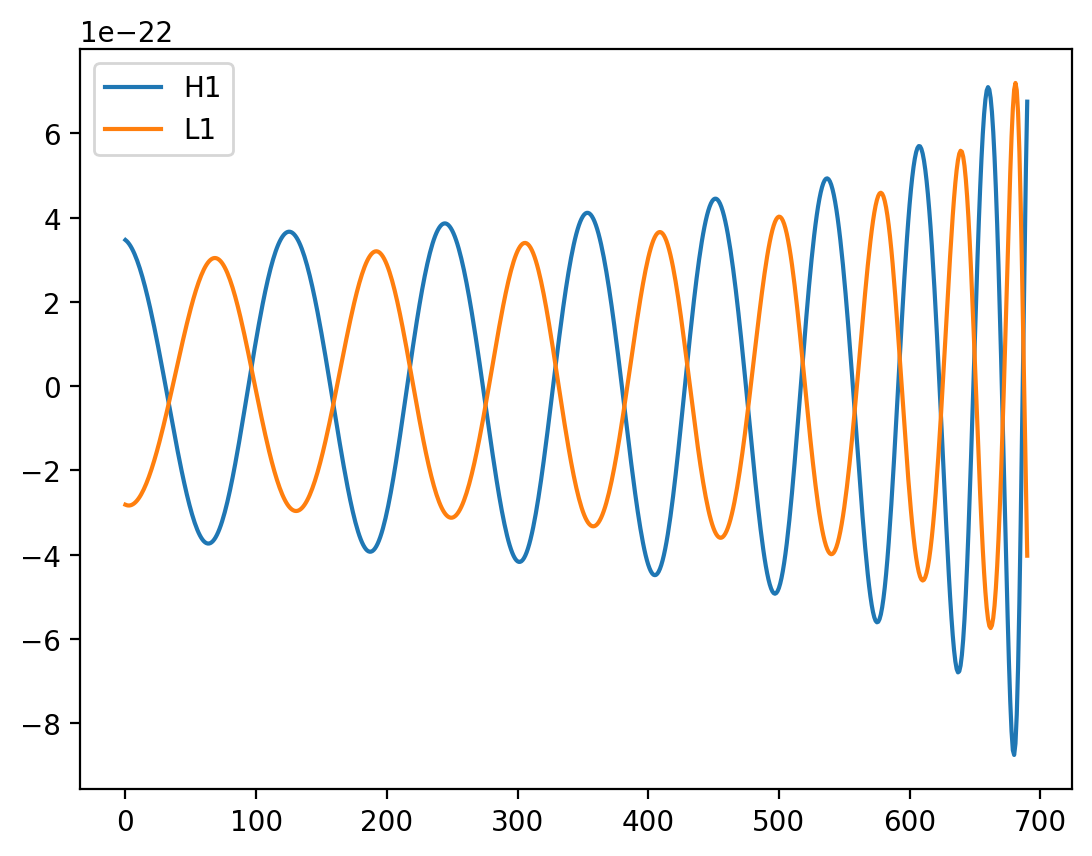

In [47]:
for i, d in coll[sidx].analysis_data.items():
    plt.plot(d, label=i)

plt.legend()

In [48]:
wd = temp_fit.whiten(coll[sidx].analysis_data)
cumsnr = {i: np.sqrt(np.cumsum(d*d)) for i, d in wd.items()}
ppSNR = float(np.linalg.norm([cs[-1] for cs in cumsnr.values()]))
print(ppSNR)

33.41296352352089


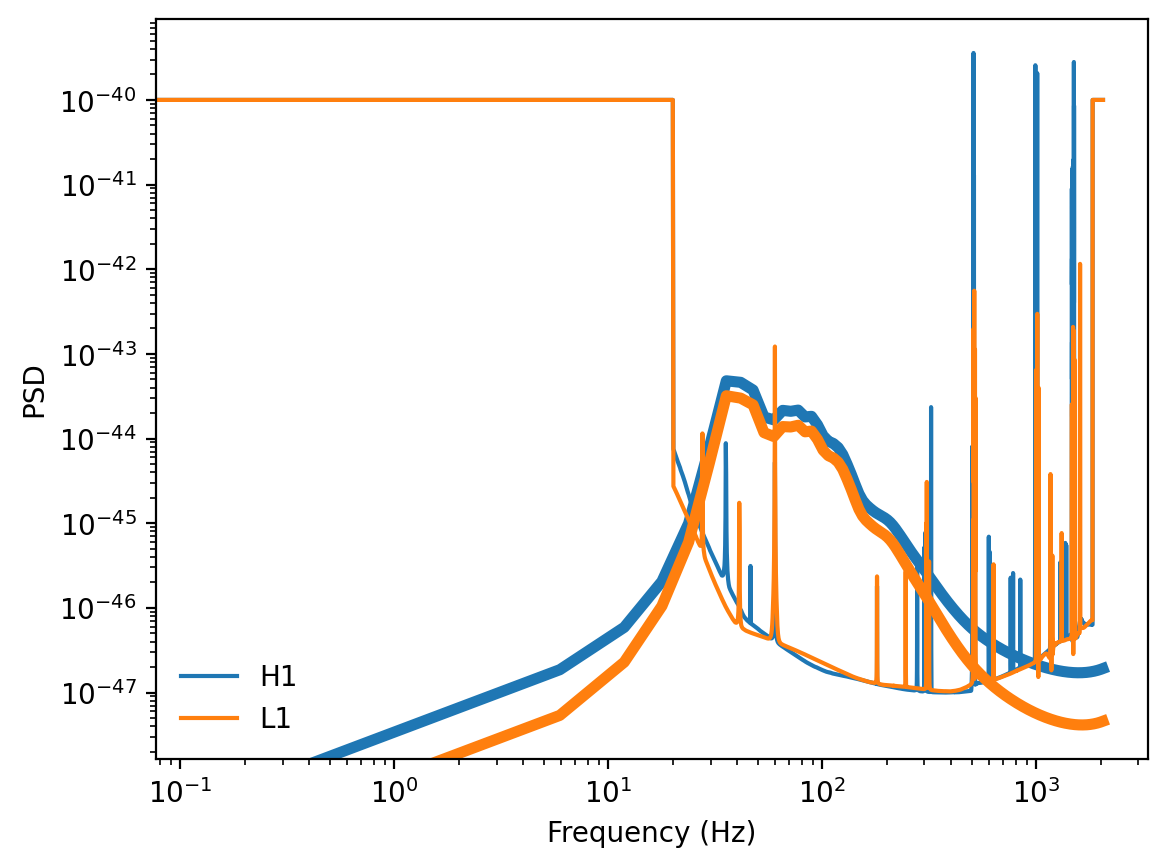

In [49]:
fig, ax = plt.subplots()
for i, psd in temp_fit.psds.items():
    l, = ax.loglog(psd, label=i)
    dt = temp_fit.analysis_data[i].delta_t
    h_freq = np.fft.rfft(coll[sidx].analysis_data[i])*dt
    fs = np.fft.rfftfreq(len(coll[sidx].analysis_data[i]), d=dt)
    ax.loglog(fs, 4*fs*np.abs(h_freq)**2, lw=4, color=l.get_color())
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
# ax.set_title('Ringup-only injection')
ax.legend(frameon=False)

Text(0, 0.5, 'PSD')

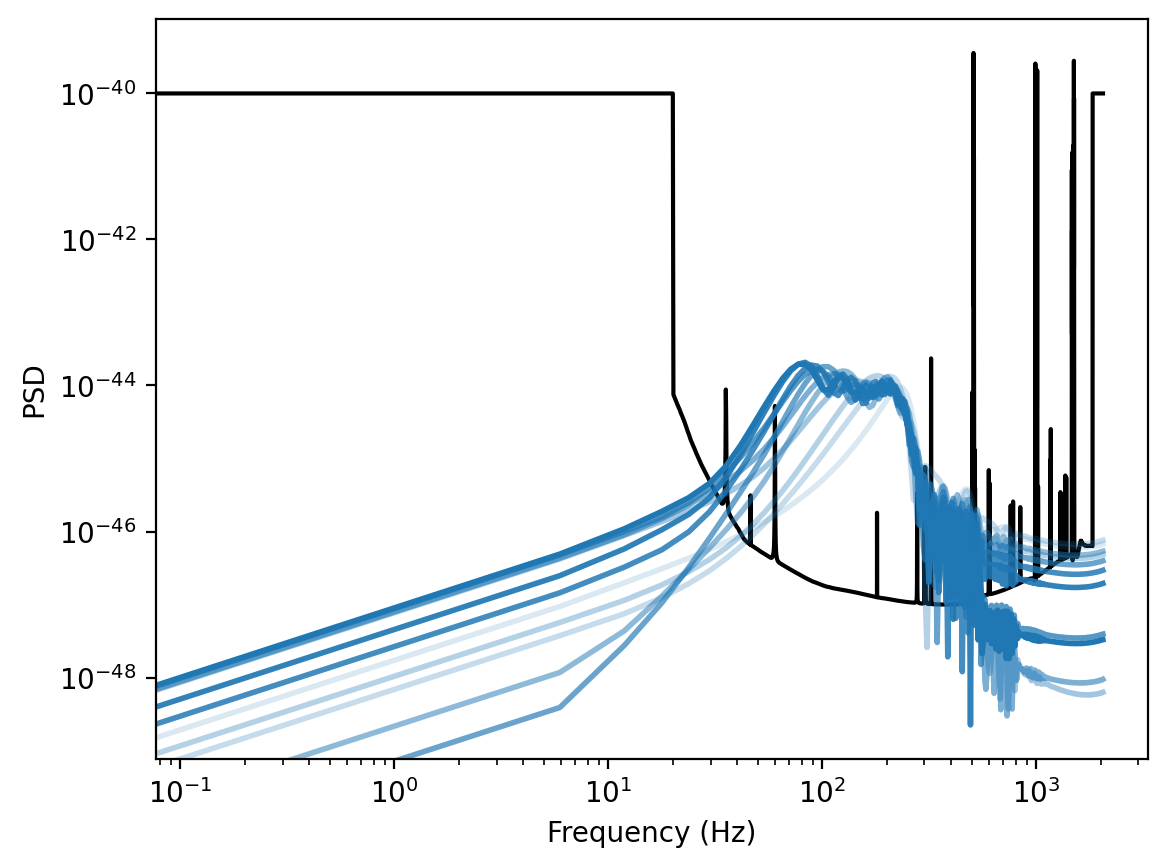

In [207]:
ifo = 'H1'

fig, ax = plt.subplots()
# for i, psd in temp_fit.psds.items():
l, = ax.loglog(temp_fit.psds[ifo], label=ifo, color='k')
dt = temp_fit.analysis_data[ifo].delta_t

for i, (s, res) in enumerate(coll.idx.items()):
    h = res.analysis_data[ifo] 
    # h_ext = np.concatenate([np.zeros(len(h)), h])
    h_ext = h
    n_pad = len(h_ext) - len(h)

    ### tapering
    window = np.ones(len(h_ext))
    window[:n_pad] = ss.windows.tukey(2*n_pad, alpha=1.)[:n_pad]
    h_win = h_ext * window

    # plt.plot(h_ext)
    
    h_freq = np.fft.rfft(h_ext)*dt
    fs = np.fft.rfftfreq(len(h_ext), d=dt)
    ax.loglog(fs, 4*fs*np.abs(h_freq)**2, lw=2, color='C0', alpha=1-i/(len(coll)+1), label=int(s))
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
# ax.set_title('Ringup-only injection')
# ax.legend(frameon=False, title=)

In [92]:
n_pad = 3

a = np.arange(0, 10)

len(a), len(a[n_pad:])

(10, 7)

In [108]:
int(len(h)/1.1), len(h)

(2879, 3168)

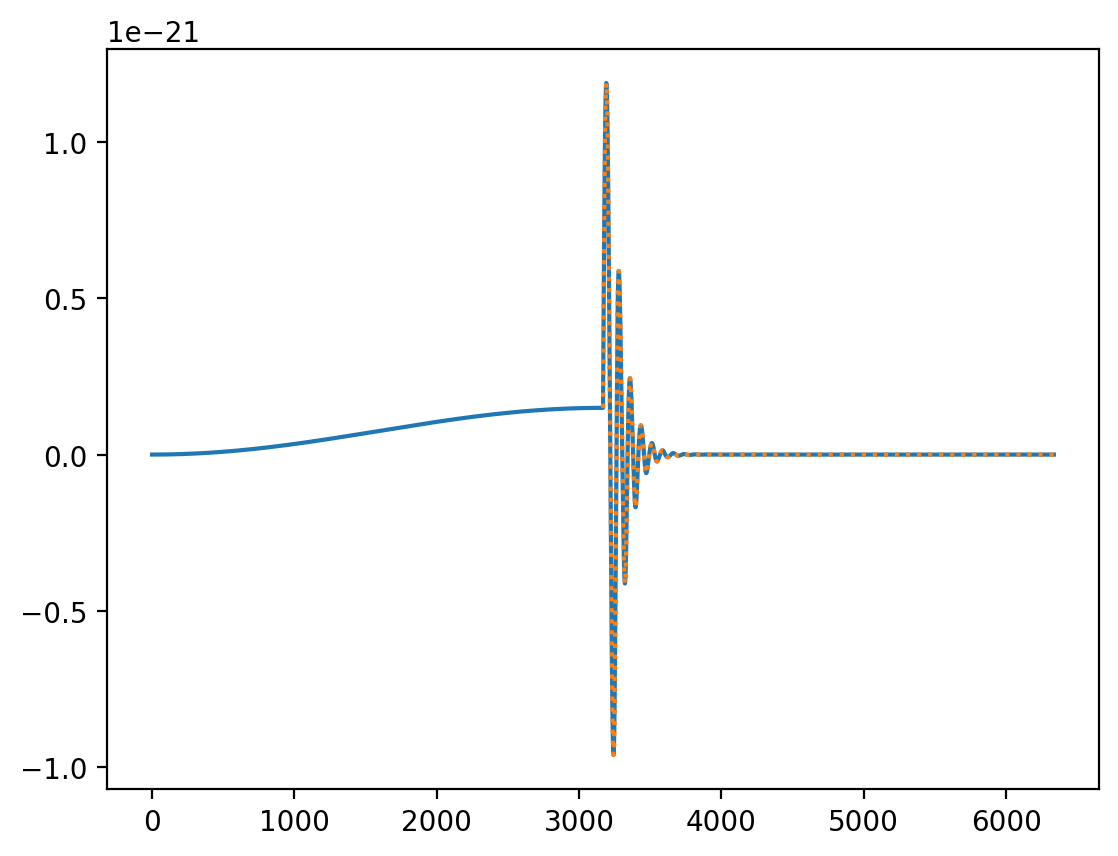

In [118]:
h = coll[sidx].analysis_data[ifo] 
# n_pad = int(len(h)/5)
h_ext = np.concatenate([np.ones(len(h))*h[0], h])
n_pad = len(h_ext) - len(h)

### tapering
window = np.ones(len(h_ext))
window[:n_pad] = ss.windows.tukey(2*n_pad, alpha=1.)[:n_pad]
h_win = h_ext * window

# plt.plot(np.arange(0, n_pad), h)
plt.plot(h_win, ls='-')
plt.plot(np.arange(0, len(h))+n_pad, h, ls=':')

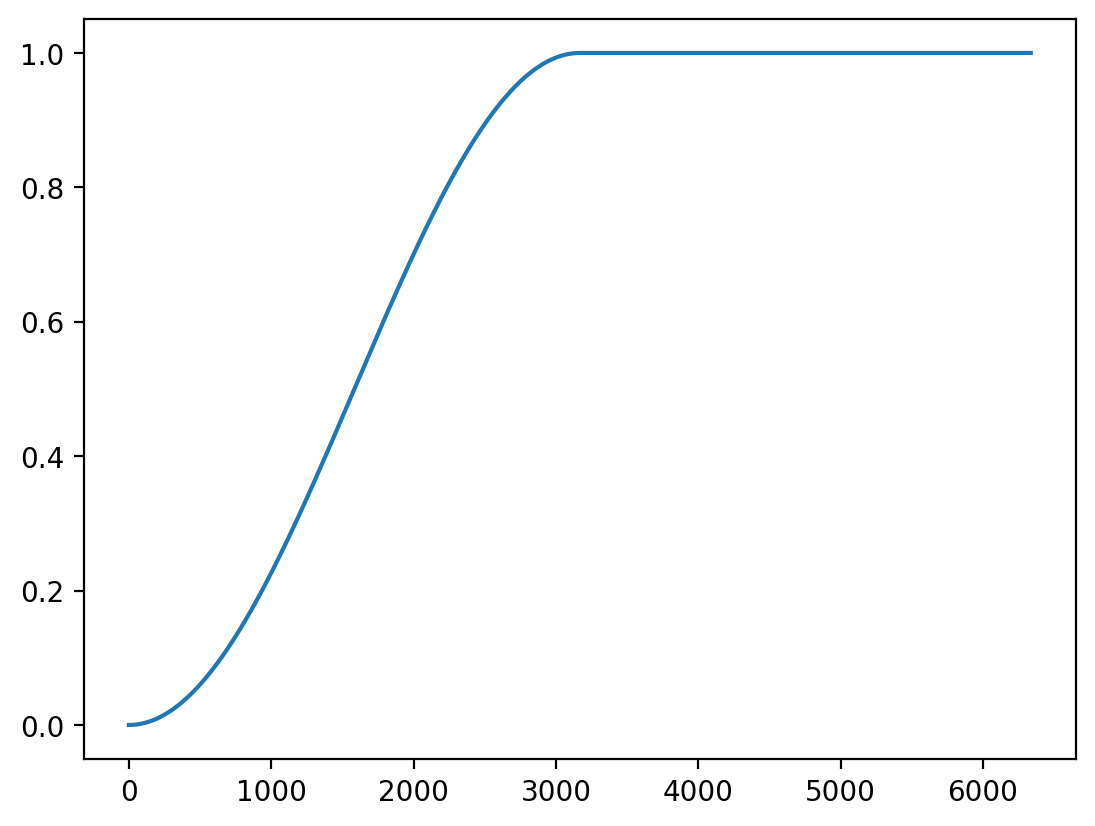

In [119]:
plt.plot(window)

In [37]:
(1/50) / tm

### roughly how many Ms in one period of the ringdown

12.93036216401957

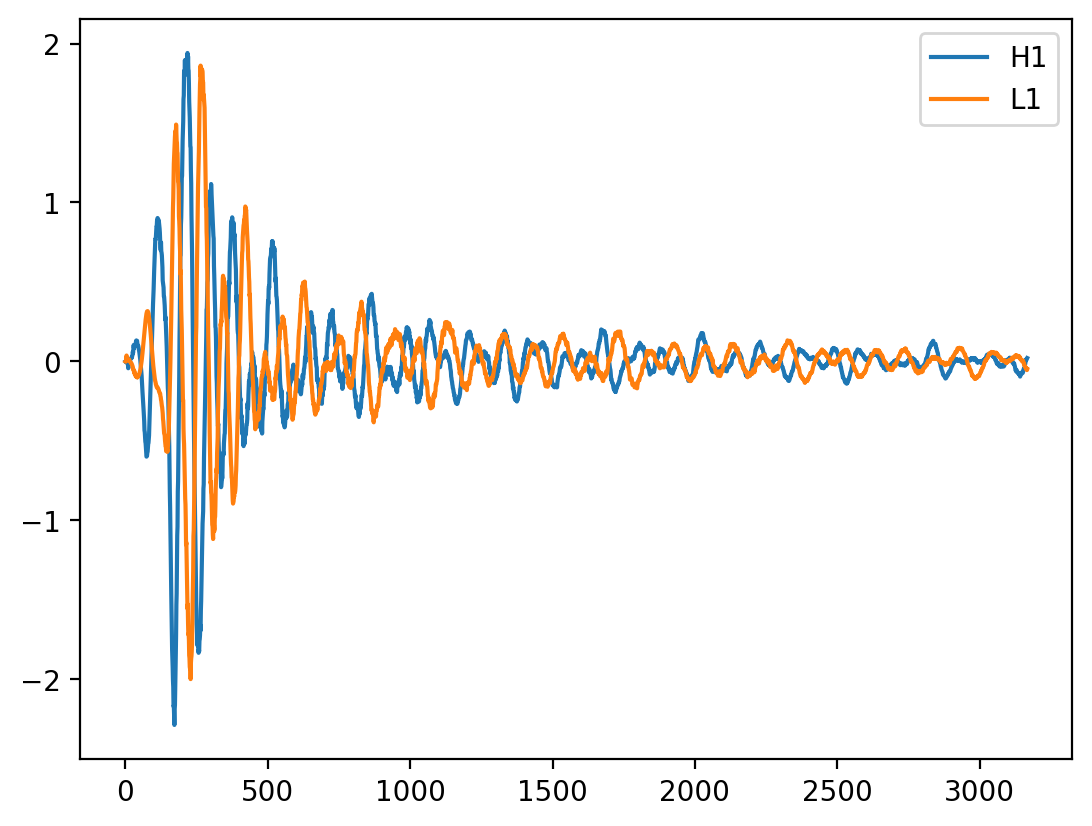

In [38]:
for i, d in wd.items():
    plt.plot(d, label=i)

plt.legend()

In [54]:
df = coll.get_parameter_dataframe(ndraw=500, prng=13)

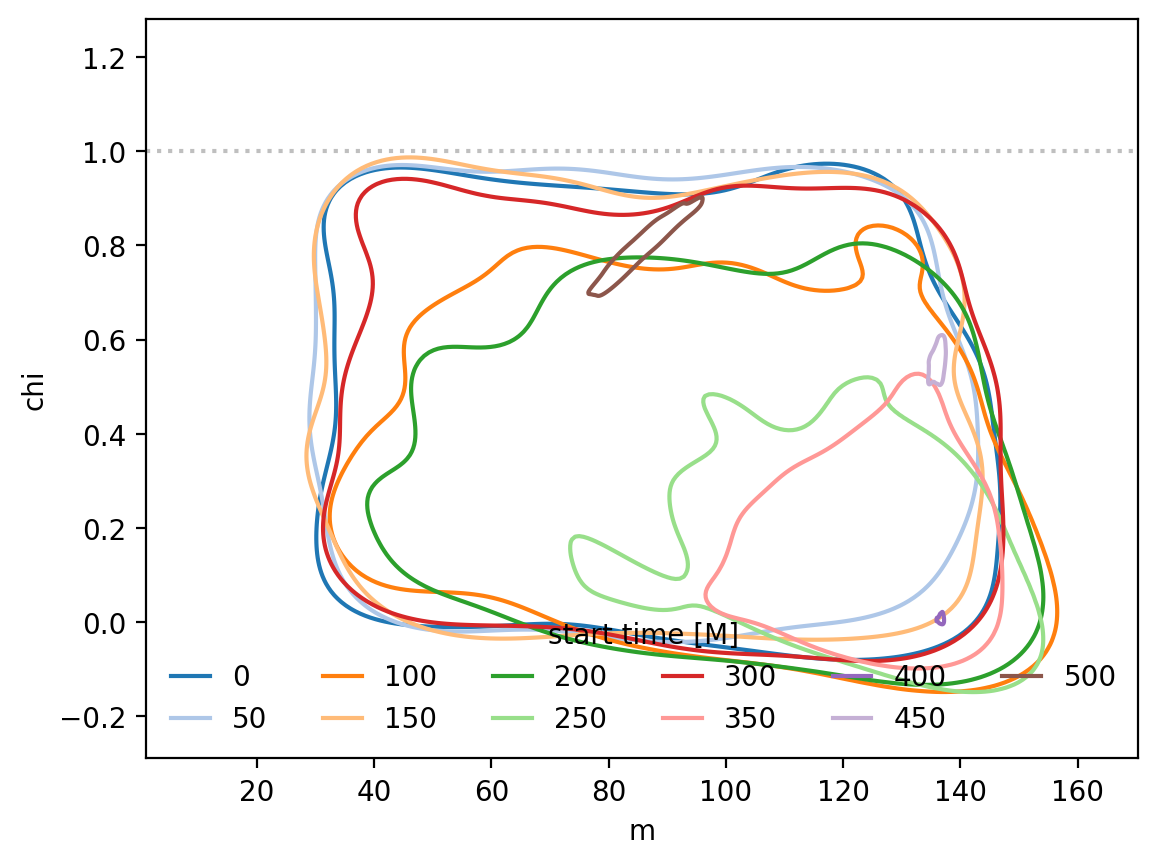

In [55]:
for i, run in enumerate(df['run'].unique()):
    l, = plt.plot([], [], label=int(run), color=sns.color_palette('tab20')[i])
    sns.kdeplot(df[df['run'] == run], x='m', y='chi', levels=[1-0.864], color=l.get_color())

plt.legend(ncol=6, title='start time [M]', frameon=False, handlelength=1.4)

plt.axhline(1, color='k', ls=':', alpha=0.25)
# plt.axhline(0.95, color='k', ls=':', alpha=0.5)

(0.0, 1e-20)

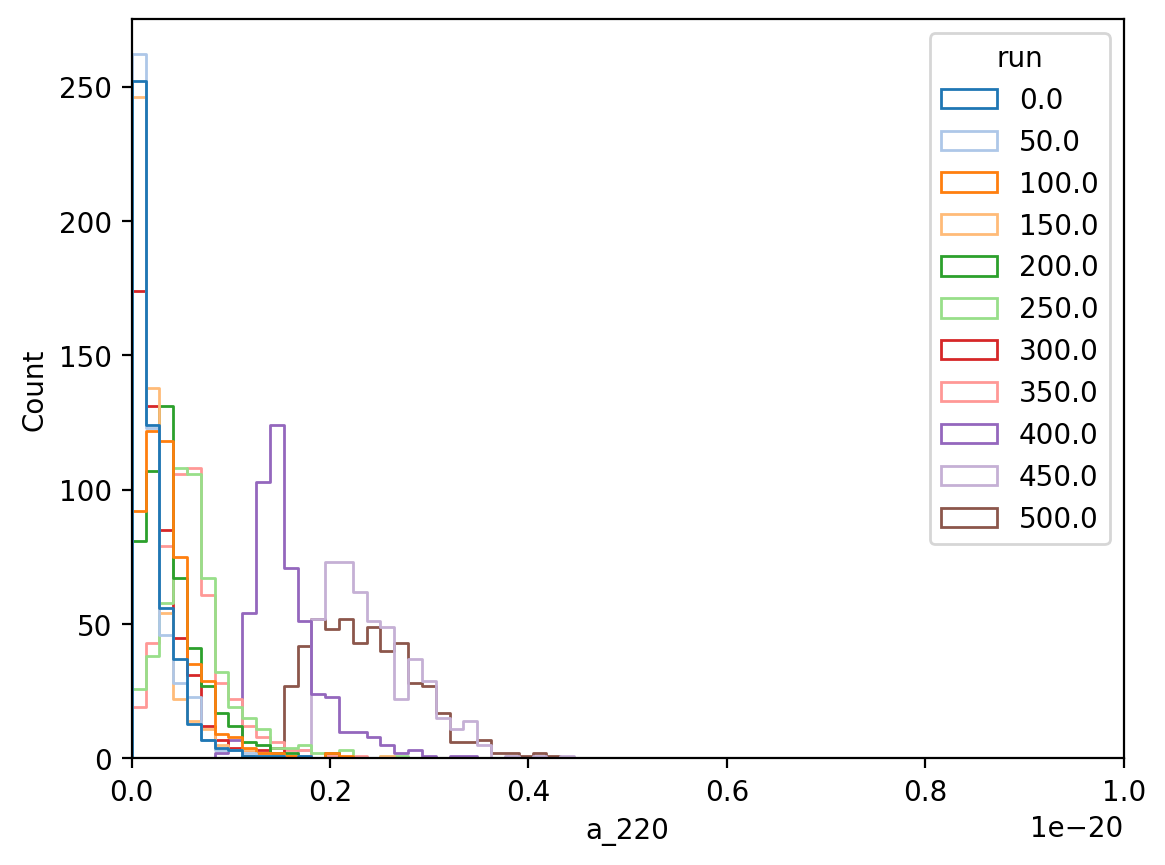

In [57]:
sns.histplot(df, x='a_220', hue='run', element='step', alpha=0, palette='tab20')
plt.xlim(0, 1e-20)

(0.0, 5.722840440690714e-20)

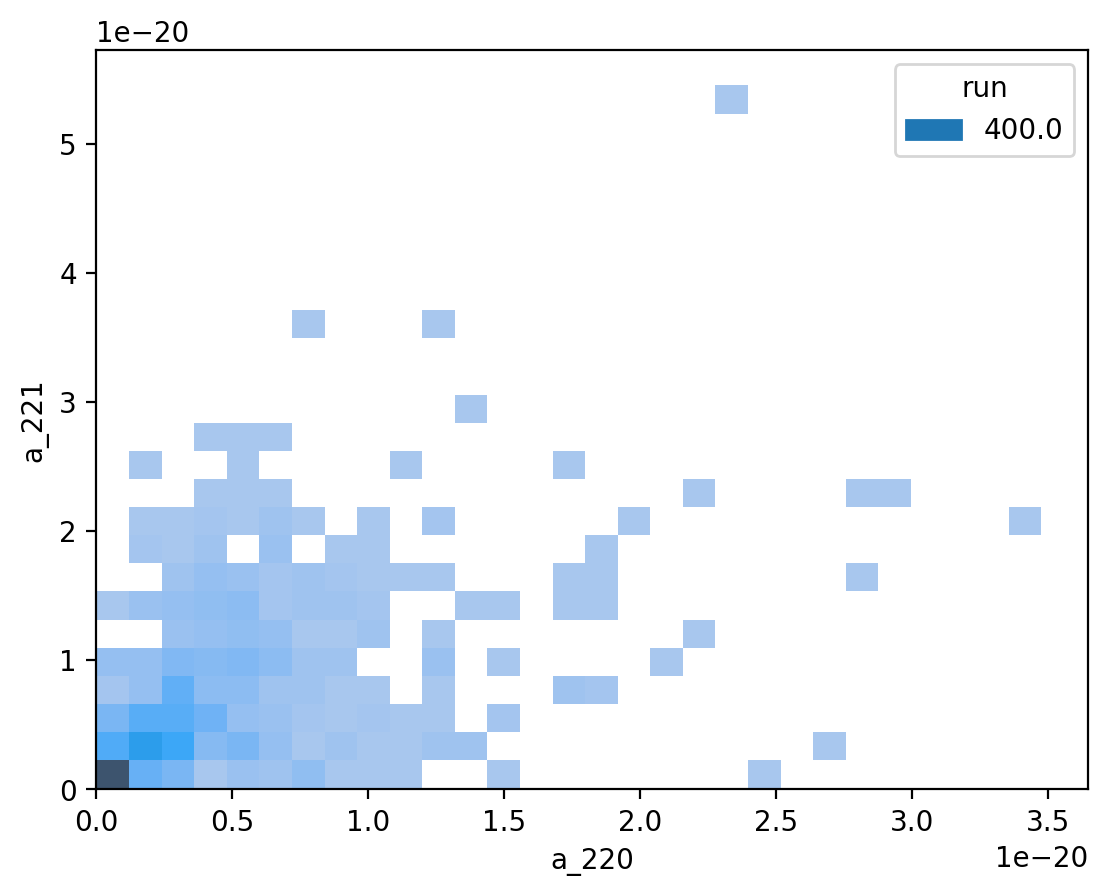

In [260]:
sns.histplot(df[df['run'] == 400], x='a_220', y='a_221', hue='run', palette='tab10')
plt.xlim(0)
plt.ylim(0)

In [1141]:
# rang = az.hdi(coll[-2].posterior.a[:,:,0].values.flatten(), 0.9)

# sns.histplot(coll[-2].posterior.a[:,:,0].values.flatten(), element='step', alpha=0)
# plt.axvspan(rang[0], rang[1], alpha=0.2)

# plt.xlim(0)